# Tarea 1
## Mario Alejandro Castro Lerma

### Parte 1: Diseño
1. **Describe el problema** que resolverá tu metaheurística

Está diseñada para resolver problemas de optimización continua, especialmente aquellos donde existen múltiples mínimos o máximos locales que dificultan encontrar la mejor solución global.

El objetivo principal del algoritmo es encontrar el óptimo global manteniendo un balance entre exploración del espacio de búsqueda y refinamiento de soluciones prometedoras.

2. **Explica tu metaheurística**: ¿Qué metáfora utiliza?, ¿Cómo balancea exploración y explotación?

La metaheurística propuesta se llama Lost Explorers Optimization (LEO):

La metáfora se basa en un grupo de exploradores perdidos en una región montañosa que intentan encontrar el punto más alto para aumentar sus posibilidades de reunirse y ser rescatados.

Cada explorador comienza en una posición aleatoria distinta dentro del terreno. De manera individual: explora regiones cercanas, evalúa si encuentra una posición mejor, y comparte información con el resto del grupo.

Cuando uno de los exploradores encuentra una mejor ubicación, los demás comienzan a desplazarse parcialmente hacia esa región, aunque continúan explorando localmente de forma independiente. Conforme avanza el algoritmo, el grupo tiende a reunirse alrededor de las mejores zonas encontradas.

El liderazgo dentro del grupo es dinámico, cualquier explorador puede convertirse en el nuevo líder si encuentra una solución superior.

La fórmula principal es con base a vectores:

movement = actual + random_walk + α(global_best − current)

donde:
- actual = posicion actual
- random_walk = exploración aleatoria,
- global_best - current = dirección hacia el líder,
- α = fuerza de atracción social (Es un parametro modificable).

### Parte 2: Implementación

### LOST EXPLORERS OPTIMIZATION (LEO)

In [2]:
# ============================================================
# LOST EXPLORERS OPTIMIZATION (LEO)
# Versión con inicialización aleatoria
# ============================================================

# ============================================================
# LOST EXPLORERS OPTIMIZATION
# ============================================================

class LostExplorersOptimization:
    
    def __init__(
        self,
        objective_function,
        bounds,
        num_explorers=4,
        max_iters=150,
        local_step=0.5,
        attraction_strength=0.3,
        exploration_decay=0.99
    ):
        
        self.f = objective_function
        self.bounds = bounds
        
        self.num_explorers = num_explorers
        self.max_iters = max_iters
        
        self.local_step = local_step
        self.attraction_strength = attraction_strength
        self.exploration_decay = exploration_decay
        
        self.dim = len(bounds)
    
    # ========================================================
    # Inicialización aleatoria
    # ========================================================
    
    def initialize_explorers(self):
        
        explorers = []
        
        for _ in range(self.num_explorers):
            
            position = [
                np.random.uniform(low, high)
                for low, high in self.bounds
            ]
            
            explorers.append(position)
        
        return np.array(explorers)
    
    # ========================================================
    # Limitar posiciones
    # ========================================================
    
    def clip_position(self, position):
        
        clipped = np.empty_like(position)
        
        for i, (low, high) in enumerate(self.bounds):
            clipped[i] = np.clip(position[i], low, high)
        
        return clipped
    
    # ========================================================
    # Optimización principal
    # ========================================================
    
    def optimize(self):
        
        explorers = self.initialize_explorers()
        
        scores = np.array([
            self.f(exp) for exp in explorers
        ])
        
        # Mejor explorador inicial
        
        best_idx = np.argmax(scores)
        
        global_best = explorers[best_idx].copy()
        global_best_score = scores[best_idx]
        
        # Historial
        
        history = []
        trajectories = [[] for _ in range(self.num_explorers)]
        diversity_history = []
        
        # ====================================================
        # Iteraciones
        # ====================================================
        
        for iteration in range(self.max_iters):
            
            for i in range(self.num_explorers):
                
                current = explorers[i]
                
                # ------------------------------------------------
                # Exploración local aleatoria
                # ------------------------------------------------
                
                random_walk = np.random.normal(
                    0,
                    self.local_step,
                    size=self.dim
                )
                
                # ------------------------------------------------
                # Atracción hacia el mejor explorador
                # ------------------------------------------------
                
                direction_to_best = global_best - current
                
                movement = (
                    random_walk
                    + self.attraction_strength * direction_to_best
                )
                
                new_position = current + movement
                
                # Limitar dentro del espacio
                
                new_position = self.clip_position(new_position)
                
                # Evaluar
                
                new_score = self.f(new_position)
                
                # ------------------------------------------------
                # Movimiento greedy
                # ------------------------------------------------
                
                if new_score > scores[i]:
                    
                    explorers[i] = new_position
                    scores[i] = new_score
                
                # Guardar trayectoria
                
                trajectories[i].append(explorers[i].copy())
            
            # =================================================
            # Actualizar líder global
            # =================================================
            
            best_idx = np.argmax(scores)
            
            if scores[best_idx] > global_best_score:
                
                global_best = explorers[best_idx].copy()
                global_best_score = scores[best_idx]
            
            # =================================================
            # Reducir exploración gradualmente
            # =================================================
            
            self.local_step *= self.exploration_decay
            
            # =================================================
            # Diversidad poblacional
            # =================================================
            
            center = np.mean(explorers, axis=0)
            
            diversity = np.mean([
                np.linalg.norm(exp - center)
                for exp in explorers
            ])
            
            diversity_history.append(diversity)
            
            history.append(global_best_score)
        
        return {
            "best_position": global_best,
            "best_score": global_best_score,
            "history": history,
            "trajectories": trajectories,
            "diversity": diversity_history
        }





In [ ]:
# ============================================================
# Benchmarks para Lost Explorers Optimization (LEO)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
# ============================================================
# FUNCIONES BENCHMARK
# ============================================================


def sphere(position):
    x, y = position
    return -(x**2 + y**2)


def rastrigin(position):
    x, y = position
    
    value = (
        20
        + x**2
        + y**2
        - 10*np.cos(2*np.pi*x)
        - 10*np.cos(2*np.pi*y)
    )
    
    return -value


def ackley(position):
    x, y = position
    
    value = (
        -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
        - np.exp(0.5 * (
            np.cos(2*np.pi*x)
            + np.cos(2*np.pi*y)
        ))
        + np.e
        + 20
    )
    
    return -value


def rosenbrock(position):
    x, y = position
    
    value = (1 - x)**2 + 100 * (y - x**2)**2
    
    return -value


def himmelblau(position):
    x, y = position
    
    value = (
        (x**2 + y - 11)**2
        + (x + y**2 - 7)**2
    )
    
    return -value


Benchmark: Sphere
Mejor posición encontrada: [-0.00244548  0.00857975]
Mejor score encontrado: -0.000080
Tiempo: 0.3679 segundos

Benchmark: Rastrigin
Mejor posición encontrada: [0.96191626 0.01218402]
Mejor score encontrado: -1.239648
Tiempo: 0.0241 segundos

Benchmark: Ackley
Mejor posición encontrada: [-0.00022589 -0.00189533]
Mejor score encontrado: -0.005496
Tiempo: 0.0263 segundos

Benchmark: Rosenbrock
Mejor posición encontrada: [0.81953045 0.68232616]
Mejor score encontrado: -0.044010
Tiempo: 0.0244 segundos

Benchmark: Himmelblau
Mejor posición encontrada: [2.99125024 2.00754646]
Mejor score encontrado: -0.002476
Tiempo: 0.0242 segundos



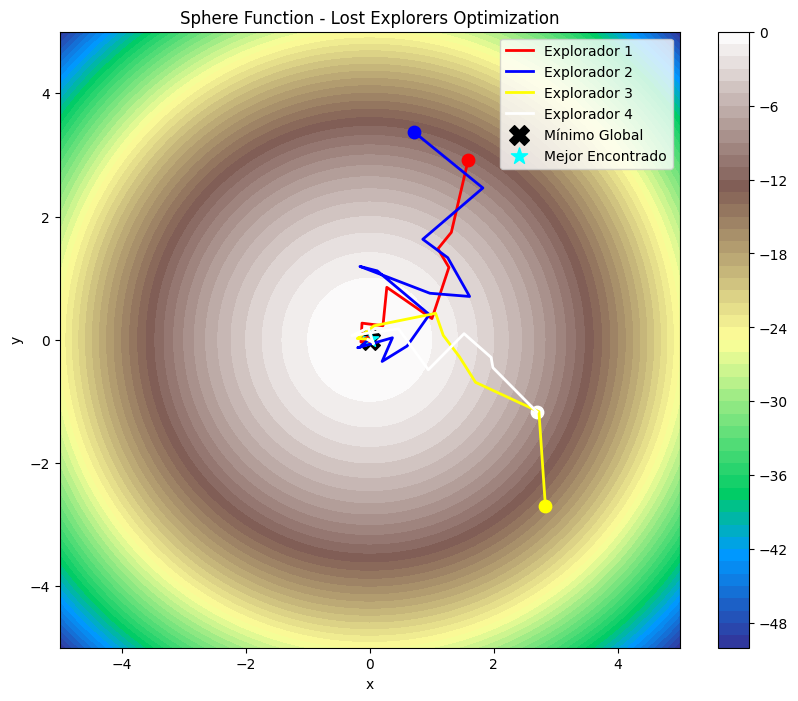

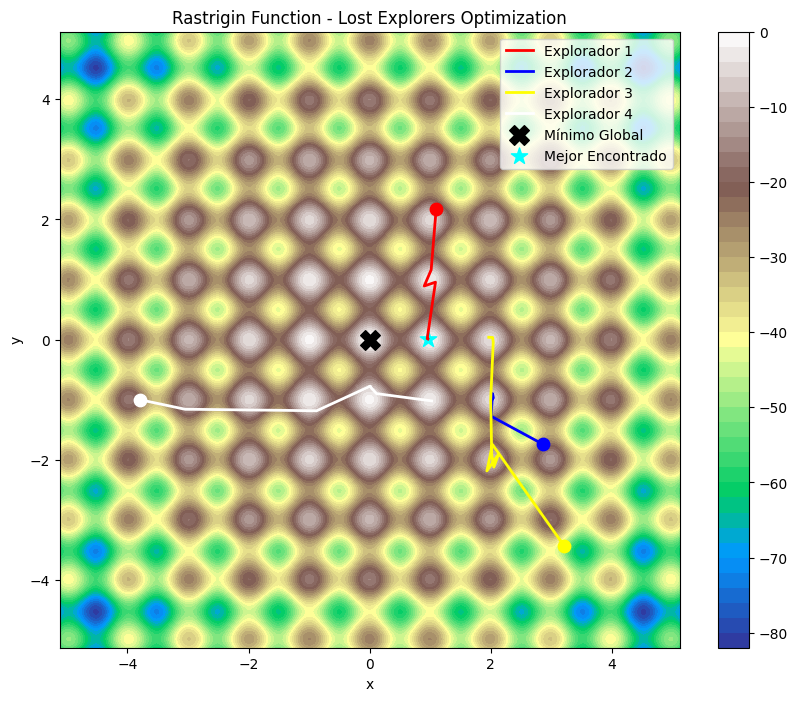

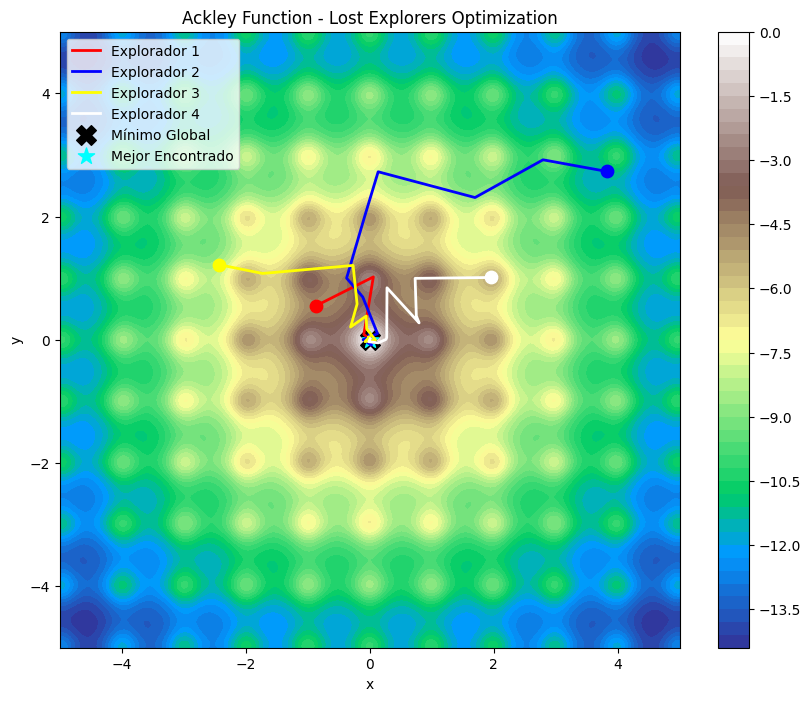

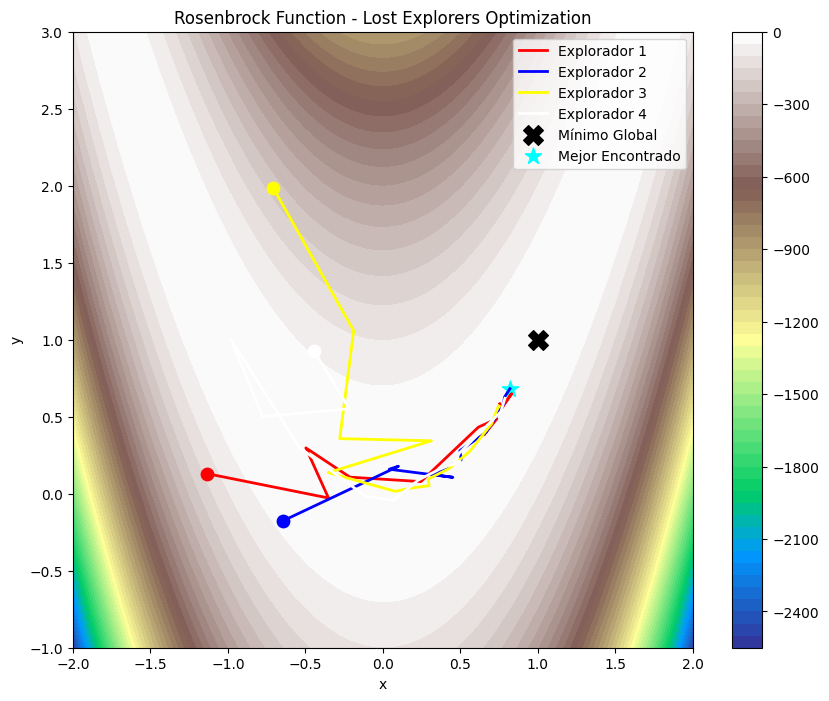

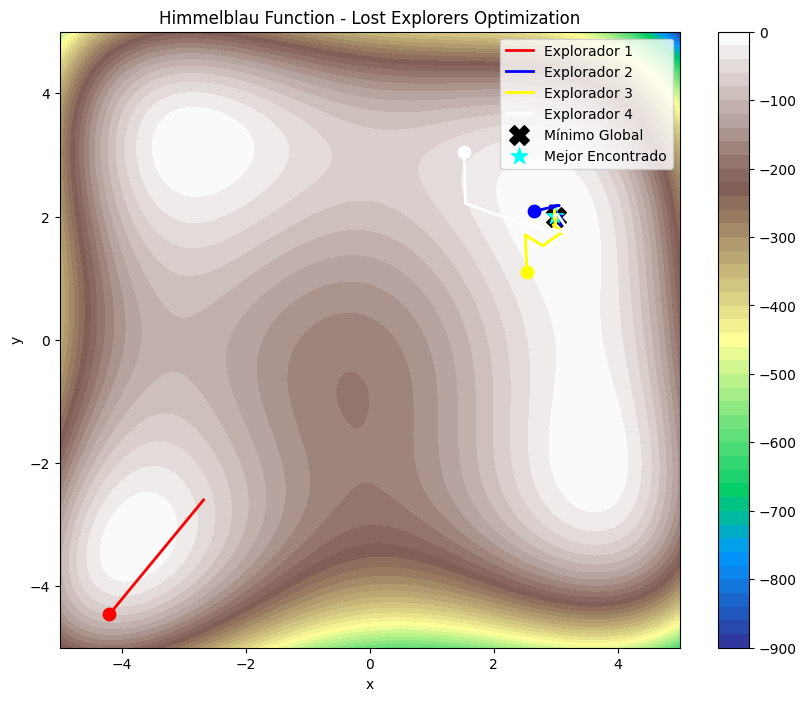

In [4]:
# ============================================================
# CONFIGURACIÓN DE BENCHMARKS
# ============================================================

benchmarks = {
    "Sphere": {
        "function": sphere,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (0, 0)
    },
    
    "Rastrigin": {
        "function": rastrigin,
        "bounds": [(-5.12, 5.12), (-5.12, 5.12)],
        "global_min": (0, 0)
    },
    
    "Ackley": {
        "function": ackley,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (0, 0)
    },
    
    "Rosenbrock": {
        "function": rosenbrock,
        "bounds": [(-2, 2), (-1, 3)],
        "global_min": (1, 1)
    },
    
    "Himmelblau": {
        "function": himmelblau,
        "bounds": [(-5, 5), (-5, 5)],
        "global_min": (3, 2)
    }
}

# ============================================================
# EJECUTAR BENCHMARKS
# ============================================================

results = {}

for name, benchmark in benchmarks.items():
    
    print("=" * 50)
    print(f"Benchmark: {name}")
    print("=" * 50)
    
    optimizer = LostExplorersOptimization(
        objective_function=benchmark["function"],
        bounds=benchmark["bounds"],
        num_explorers=4
    )
    
    start = time.time()
    
    result = optimizer.optimize()
    
    end = time.time()
    
    results[name] = result
    
    print(f"Mejor posición encontrada: {result['best_position']}")
    print(f"Mejor score encontrado: {result['best_score']:.6f}")
    print(f"Tiempo: {end - start:.4f} segundos")
    
    print()
    


# ============================================================
# VISUALIZACIÓN DE CADA BENCHMARK
# ============================================================

for name, benchmark in benchmarks.items():
    
    f = benchmark["function"]
    bounds = benchmark["bounds"]
    global_min = benchmark["global_min"]
    
    result = results[name]
    
    # --------------------------------------------------------
    # Crear malla
    # --------------------------------------------------------
    
    x = np.linspace(bounds[0][0], bounds[0][1], 300)
    y = np.linspace(bounds[1][0], bounds[1][1], 300)
    
    X, Y = np.meshgrid(x, y)
    
    Z = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f([X[i, j], Y[i, j]])
    
    # ========================================================
    # Gráfica principal
    # ========================================================
    
    plt.figure(figsize=(10, 8))
    
    contour = plt.contourf(
        X,
        Y,
        Z,
        levels=50,
        cmap="terrain"
    )
    
    plt.colorbar(contour)
    
    # --------------------------------------------------------
    # Dibujar trayectorias
    # --------------------------------------------------------
    
    colors = ["red", "blue", "yellow", "white"]
    
    for i, trajectory in enumerate(result["trajectories"]):
        
        trajectory = np.array(trajectory)
        
        plt.plot(
            trajectory[:, 0],
            trajectory[:, 1],
            color=colors[i],
            linewidth=2,
            label=f"Explorador {i+1}"
        )
        
        plt.scatter(
            trajectory[0, 0],
            trajectory[0, 1],
            color=colors[i],
            s=80
        )
    
    # --------------------------------------------------------
    # Mínimo global real
    # --------------------------------------------------------
    
    plt.scatter(
        global_min[0],
        global_min[1],
        color="black",
        s=200,
        marker="X",
        label="Mínimo Global"
    )
    
    # --------------------------------------------------------
    # Mejor solución encontrada
    # --------------------------------------------------------
    
    best = result["best_position"]
    
    plt.scatter(
        best[0],
        best[1],
        color="cyan",
        s=150,
        marker="*",
        label="Mejor Encontrado"
    )
    
    plt.title(f"{name} Function - Lost Explorers Optimization")
    
    plt.xlabel("x")
    plt.ylabel("y")
    
    plt.legend()
    
    plt.show()

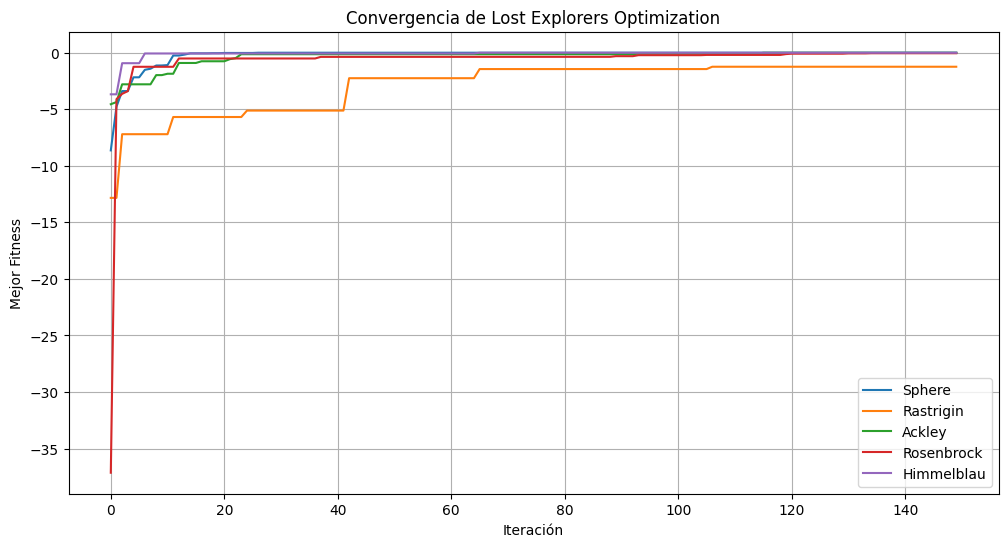

In [5]:
# ============================================================
# COMPARACIÓN DE CONVERGENCIA
# ============================================================

plt.figure(figsize=(12, 6))

for name, result in results.items():
    
    plt.plot(
        result["history"],
        label=name
    )

plt.title("Convergencia de Lost Explorers Optimization")
plt.xlabel("Iteración")
plt.ylabel("Mejor Fitness")

plt.legend()

plt.grid(True)

plt.show()

### Parte 3: Evaluación
1. **Compara** con al menos un método base (random search, hill climbing)
2. **Mide** tiempo de ejecución y calidad de solución
3. **Analiza** fortalezas y debilidades

In [ ]:
# ============================================================
# COMPARACIÓN DE LEO VS RANDOM SEARCH VS HILL CLIMBING
# ============================================================



# ============================================================
# FUNCIÓN BENCHMARK
# ============================================================

benchmark_function = rastrigin

bounds = [(-5.12, 5.12), (-5.12, 5.12)]

# ============================================================
# RANDOM SEARCH
# ============================================================

def random_search(
    objective_function,
    bounds,
    iterations=150
):
    
    best_position = None
    best_score = -np.inf
    
    history = []
    
    start = time.time()
    
    for _ in range(iterations):
        
        position = np.array([
            np.random.uniform(low, high)
            for low, high in bounds
        ])
        
        score = objective_function(position)
        
        if score > best_score:
            
            best_score = score
            best_position = position.copy()
        
        history.append(best_score)
    
    end = time.time()
    
    return {
        "best_position": best_position,
        "best_score": best_score,
        "history": history,
        "time": end - start
    }


# ============================================================
# HILL CLIMBING
# ============================================================

def hill_climbing(
    objective_function,
    bounds,
    iterations=150,
    step_size=0.5
):
    
    current = np.array([
        np.random.uniform(low, high)
        for low, high in bounds
    ])
    
    current_score = objective_function(current)
    
    best_position = current.copy()
    best_score = current_score
    
    history = []
    
    start = time.time()
    
    for _ in range(iterations):
        
        candidate = current + np.random.normal(
            0,
            step_size,
            size=len(bounds)
        )
        
        # Mantener límites
        
        for i, (low, high) in enumerate(bounds):
            candidate[i] = np.clip(candidate[i], low, high)
        
        candidate_score = objective_function(candidate)
        
        # Movimiento greedy
        
        if candidate_score > current_score:
            
            current = candidate
            current_score = candidate_score
            
            if current_score > best_score:
                
                best_position = current.copy()
                best_score = current_score
        
        history.append(best_score)
    
    end = time.time()
    
    return {
        "best_position": best_position,
        "best_score": best_score,
        "history": history,
        "time": end - start
    }


# ============================================================
# LOST EXPLORERS OPTIMIZATION (LEO)
# ============================================================

start = time.time()

leo = LostExplorersOptimization(
    objective_function=benchmark_function,
    bounds=bounds
)

leo_result = leo.optimize()

end = time.time()

leo_result["time"] = end - start


# ============================================================
# EJECUTAR BASELINES
# ============================================================

random_result = random_search(
    benchmark_function,
    bounds
)

hill_result = hill_climbing(
    benchmark_function,
    bounds
)


# ============================================================
# TABLA DE RESULTADOS
# ============================================================

results_df = pd.DataFrame({
    "Algoritmo": [
        "Random Search",
        "Hill Climbing",
        "Lost Explorers Optimization"
    ],
    
    "Mejor Score": [
        random_result["best_score"],
        hill_result["best_score"],
        leo_result["best_score"]
    ],
    
    "Tiempo (s)": [
        random_result["time"],
        hill_result["time"],
        leo_result["time"]
    ]
})

results_df

,Algoritmo,Mejor Score,Tiempo (s)
0,Random Search,-5.817854,0.001754
1,Hill Climbing,-1.378302,0.002878
2,Lost Explorers Optimization,-0.046807,0.025276


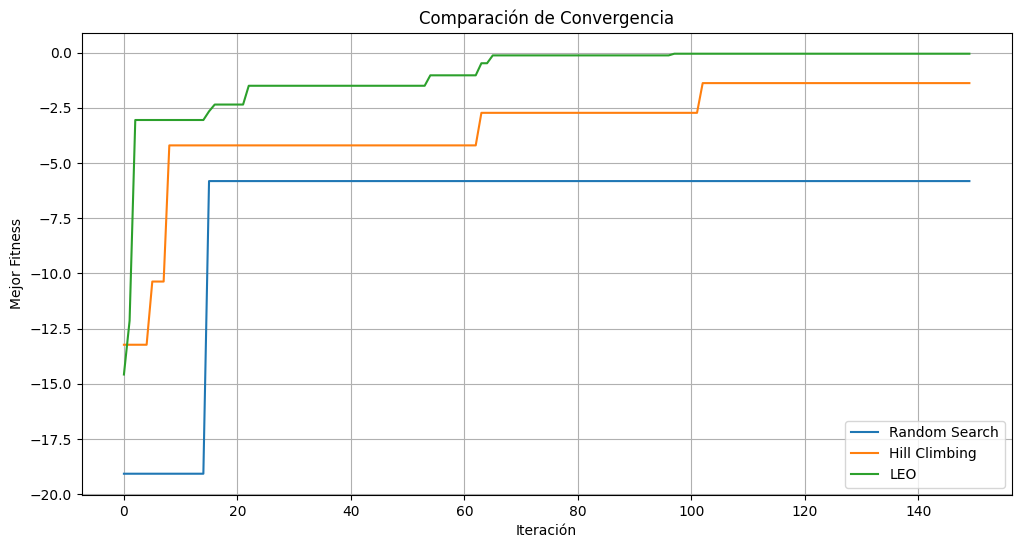

In [7]:
# ============================================================
# COMPARACIÓN DE CONVERGENCIA
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    random_result["history"],
    label="Random Search"
)

plt.plot(
    hill_result["history"],
    label="Hill Climbing"
)

plt.plot(
    leo_result["history"],
    label="LEO"
)

plt.title("Comparación de Convergencia")
plt.xlabel("Iteración")
plt.ylabel("Mejor Fitness")

plt.legend()

plt.grid(True)

plt.show()

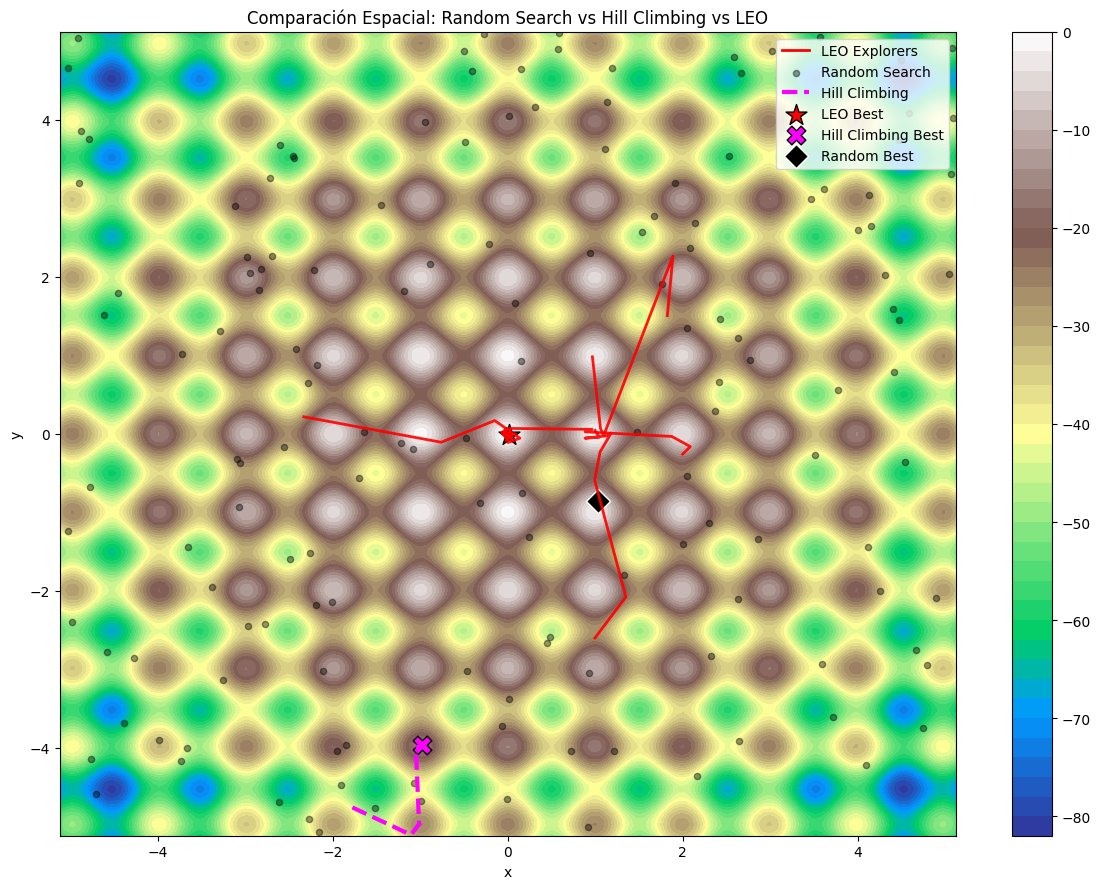

In [11]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA CORREGIDA
# Random Search vs Hill Climbing vs LEO
# ============================================================

x = np.linspace(bounds[0][0], bounds[0][1], 300)
y = np.linspace(bounds[1][0], bounds[1][1], 300)

X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        
        Z[i, j] = benchmark_function([
            X[i, j],
            Y[i, j]
        ])

# ============================================================
# Crear figura
# ============================================================

plt.figure(figsize=(12, 9))

contour = plt.contourf(
    X,
    Y,
    Z,
    levels=50,
    cmap="terrain"
)

plt.colorbar(contour)

# ============================================================
# LEO - Trayectorias
# ============================================================

leo_colors = ["red", "red", "red", "red"]

for i, trajectory in enumerate(leo_result["trajectories"]):
    
    trajectory = np.array(trajectory)
    
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color=leo_colors[i],
        linewidth=2,
        alpha=0.9
    )

# SOLO UNA ENTRADA EN LA LEYENDA PARA LEO

plt.plot(
    [],
    [],
    color="red",
    linewidth=2,
    label="LEO Explorers"
)

# ============================================================
# RANDOM SEARCH
# ============================================================

random_points = np.array([
    [
        np.random.uniform(bounds[0][0], bounds[0][1]),
        np.random.uniform(bounds[1][0], bounds[1][1])
    ]
    for _ in range(150)
])

plt.scatter(
    random_points[:, 0],
    random_points[:, 1],
    color="black",
    s=20,
    alpha=0.4,
    label="Random Search"
)

# ============================================================
# HILL CLIMBING
# ============================================================

def hill_climbing_with_trajectory(
    objective_function,
    bounds,
    iterations=150,
    step_size=0.5
):
    
    current = np.array([
        np.random.uniform(low, high)
        for low, high in bounds
    ])
    
    current_score = objective_function(current)
    
    trajectory = [current.copy()]
    
    for _ in range(iterations):
        
        candidate = current + np.random.normal(
            0,
            step_size,
            size=len(bounds)
        )
        
        for i, (low, high) in enumerate(bounds):
            candidate[i] = np.clip(candidate[i], low, high)
        
        candidate_score = objective_function(candidate)
        
        if candidate_score > current_score:
            
            current = candidate
            current_score = candidate_score
        
        trajectory.append(current.copy())
    
    return np.array(trajectory)


hill_trajectory = hill_climbing_with_trajectory(
    benchmark_function,
    bounds
)

plt.plot(
    hill_trajectory[:, 0],
    hill_trajectory[:, 1],
    color="magenta",
    linewidth=3,
    linestyle="--",
    label="Hill Climbing"
)

# ============================================================
# Mejores soluciones
# ============================================================

# LEO

leo_best = leo_result["best_position"]

plt.scatter(
    leo_best[0],
    leo_best[1],
    color="red",
    s=250,
    marker="*",
    edgecolors="black",
    label="LEO Best"
)

# Hill Climbing

hill_best = hill_trajectory[-1]

plt.scatter(
    hill_best[0],
    hill_best[1],
    color="magenta",
    s=180,
    marker="X",
    edgecolors="black",
    label="Hill Climbing Best"
)

# Random Search

random_best = random_result["best_position"]

plt.scatter(
    random_best[0],
    random_best[1],
    color="black",
    s=150,
    marker="D",
    edgecolors="white",
    label="Random Best"
)

# ============================================================
# Configuración final
# ============================================================

plt.title("Comparación Espacial: Random Search vs Hill Climbing vs LEO")

plt.xlabel("x")
plt.ylabel("y")

plt.legend(
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

plt.show()

Analisis:

Mi metaheuristica parece tener buenos resultados y de forma consistente, aunque en las benchmarks del inicio, algunas veces sufre de las posiciones aleatorias iniciales y converge prematuramente.

Comparandola a otros metodos base, parece ser que mi modelo es mejor pero utiliza mas tiempo de computo, ya que es practicamente hill climbing con multiples agentes y vectores de direccion. Pero gracias a esto, mi modelo encuentra la mejor solucion en muchos casos.

Fortalezas:

- Exploracion distribuida
- Evita minimos locales en la mayoria de casos
- Simple ideologia detras de la metafora
- Puede ser modificada para aumentar la cantidad de "Exploradores" de forma que hay una mayor exploracion a cambio de poder de computo

Debilidades:
- Costo computacional comparado a modelos base
- La aleatoriedad inicial puede perjudicar al resultado del modelo
- Puede que sea muy simple para problemas mas complejos aunque los resultados en estas benchmarks salieran bien
- Es mas lento segun la tabla anterior, aunque parece poco ahorita, si se necesitara mas iteraciones el tiempo de esta aumenta mas que los metodos base (Estoy suponiendo, pero si se utilizaran algunos metodos para detener el modelo de forma temprana podria mejorar).